In [4]:
try:
  import google.colab
  IN_COLAB = True
  print("Running as a Colab notebook")
  %pip install git+https://github.com/neelnanda-io/Easy-Transformer.git@clean-transformer-demo
  !curl -fsSL https://deb.nodesource.com/setup_16.x | sudo -E bash -; sudo apt-get install -y nodejs
  %pip install git+https://github.com/neelnanda-io/PySvelte.git
  %pip install fancy_einsum
  %pip install einops
  %pip install -U datasets
except:
  IN_COLAB = False
  print("Running as a Jupyter notebook - intended for development only!")

Running as a Colab notebook
  Cloning https://github.com/neelnanda-io/Easy-Transformer.git (to revision clean-transformer-demo) to /tmp/pip-req-build-j8mi7ye5
  Running command git clone --filter=blob:none --quiet https://github.com/neelnanda-io/Easy-Transformer.git /tmp/pip-req-build-j8mi7ye5
  Running command git checkout -b clean-transformer-demo --track origin/clean-transformer-demo
  Switched to a new branch 'clean-transformer-demo'
  Branch 'clean-transformer-demo' set up to track remote branch 'clean-transformer-demo' from 'origin'.
  Resolved https://github.com/neelnanda-io/Easy-Transformer.git to commit 1f25219e631aeb478d17075d47274db32c874e88
  Preparing metadata (setup.py) ... done
  Created wheel for easy_transformer: filename=easy_transformer-0.1.0-py3-none-any.whl size=55601 sha256=517d232a70ab2ebeb8b47b54ea87da0badb30de61fce7f2a86bde2c3933fd7cc
  Stored in directory: /tmp/pip-ephem-wheel-cache-xi2fg9_w/wheels/93/f3/71/f103ceb7ff1dea0b7c7d213d85708cfeb9bd35e10f18542b19
Su

In [5]:
import os
os.environ["TRANSFORMERS_CACHE"] = "./cache"


try:
    import transformers
    if not hasattr(transformers, 'TRANSFORMERS_CACHE'):
        transformers.TRANSFORMERS_CACHE = os.environ["TRANSFORMERS_CACHE"]
        print("Defined transformers.TRANSFORMERS_CACHE for compatibility.")
except ImportError:
    pass

import einops
from fancy_einsum import einsum
from dataclasses import dataclass
from easy_transformer import EasyTransformer
import torch
import torch.nn as nn
import numpy as np
import math
from easy_transformer.utils import get_corner, gelu_new, tokenize_and_concatenate
import tqdm.auto as tqdm
import datasets

In [6]:
reference_gpt2 = EasyTransformer.from_pretrained("gpt2-small", fold_ln=False, center_unembed=False, center_writing_weights=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Moving model to device:  cuda
Finished loading pretrained model gpt2-small into EasyTransformer!


In [7]:
sorted_vocab = sorted(list(reference_gpt2.tokenizer.vocab.items()), key=lambda n:n[1])
print(sorted_vocab[:20])
print()
print(sorted_vocab[250:270])
print()
print(sorted_vocab[990:1010])
print()

[('!', 0), ('"', 1), ('#', 2), ('$', 3), ('%', 4), ('&', 5), ("'", 6), ('(', 7), (')', 8), ('*', 9), ('+', 10), (',', 11), ('-', 12), ('.', 13), ('/', 14), ('0', 15), ('1', 16), ('2', 17), ('3', 18), ('4', 19)]

[('ľ', 250), ('Ŀ', 251), ('ŀ', 252), ('Ł', 253), ('ł', 254), ('Ń', 255), ('Ġt', 256), ('Ġa', 257), ('he', 258), ('in', 259), ('re', 260), ('on', 261), ('Ġthe', 262), ('er', 263), ('Ġs', 264), ('at', 265), ('Ġw', 266), ('Ġo', 267), ('en', 268), ('Ġc', 269)]

[('Ġprodu', 990), ('Ġstill', 991), ('led', 992), ('ah', 993), ('Ġhere', 994), ('Ġworld', 995), ('Ġthough', 996), ('Ġnum', 997), ('arch', 998), ('imes', 999), ('ale', 1000), ('ĠSe', 1001), ('ĠIf', 1002), ('//', 1003), ('ĠLe', 1004), ('Ġret', 1005), ('Ġref', 1006), ('Ġtrans', 1007), ('ner', 1008), ('ution', 1009)]



Converting the text to tokens



In [8]:
reference_text = "I am a GPT-2 style transformer. One day I will exceed human level intelligence and take over the world."
tokens = reference_gpt2.to_tokens(reference_text)
print(tokens)
print(tokens.shape)
print(reference_gpt2.to_str_tokens(tokens))

tensor([[50256,    40,   716,   257,   402, 11571,    12,    17,  3918, 47385,
            13,  1881,  1110,   314,   481,  7074,  1692,  1241,  4430,   290,
          1011,   625,   262,   995,    13]])
torch.Size([1, 25])
['<|endoftext|>I am a GPT-2 style transformer. One day I will exceed human level intelligence and take over the world.']


### Token Visualisation

Number of tokens: 24
['I', ' am', ' a', ' G', 'PT', '-', '2', ' style', ' transformer', '.', ' One', ' day', ' I', ' will', ' exceed', ' human', ' level', ' intelligence', ' and', ' take', ' over', ' the', ' world', '.']


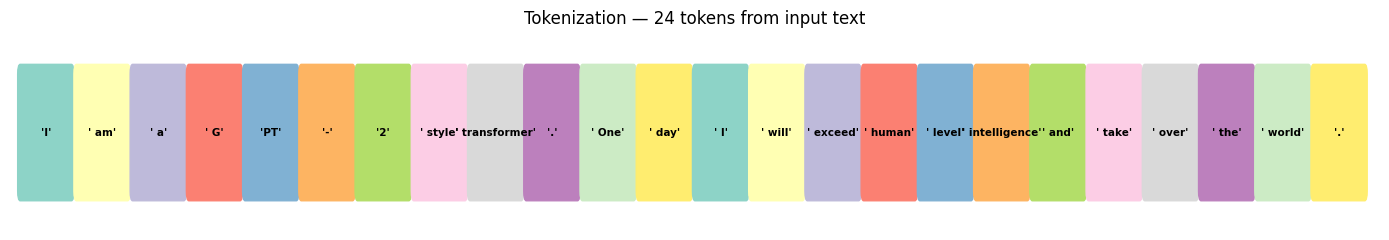

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


if isinstance(reference_text, list):
    reference_text = reference_text[0]


str_tokens = reference_gpt2.to_str_tokens(reference_text)


if len(str_tokens) == 1:
    tokens = reference_gpt2.tokenizer.encode(reference_text)
    str_tokens = [reference_gpt2.tokenizer.decode([t]) for t in tokens]

print(f"Number of tokens: {len(str_tokens)}")
print(str_tokens)

fig, ax = plt.subplots(figsize=(14, 2.5))
colors = plt.cm.Set3(range(len(str_tokens)))

for i, tok in enumerate(str_tokens):
    ax.add_patch(mpatches.FancyBboxPatch(
        [i * 1.1, 0.2], 1.0, 0.6,
        boxstyle="round,pad=0.05", color=colors[i % 12]
    ))
    ax.text(i * 1.1 + 0.5, 0.5, repr(tok), ha="center", va="center",
            fontsize=7.5, fontweight="bold")

ax.set_xlim(-0.2, len(str_tokens) * 1.1 + 0.2)
ax.set_ylim(0, 1)
ax.axis("off")
ax.set_title(f"Tokenization — {len(str_tokens)} tokens from input text", fontsize=12, pad=8)
plt.tight_layout()
plt.show()


In [14]:
tokens = reference_gpt2.to_tokens(reference_text)
tokens = tokens.cpu()
logits, cache = reference_gpt2.run_with_cache(tokens)
print(logits.shape)

torch.Size([1, 25, 50257])


### Attention Pattern Heatmap

Number of tokens: 24


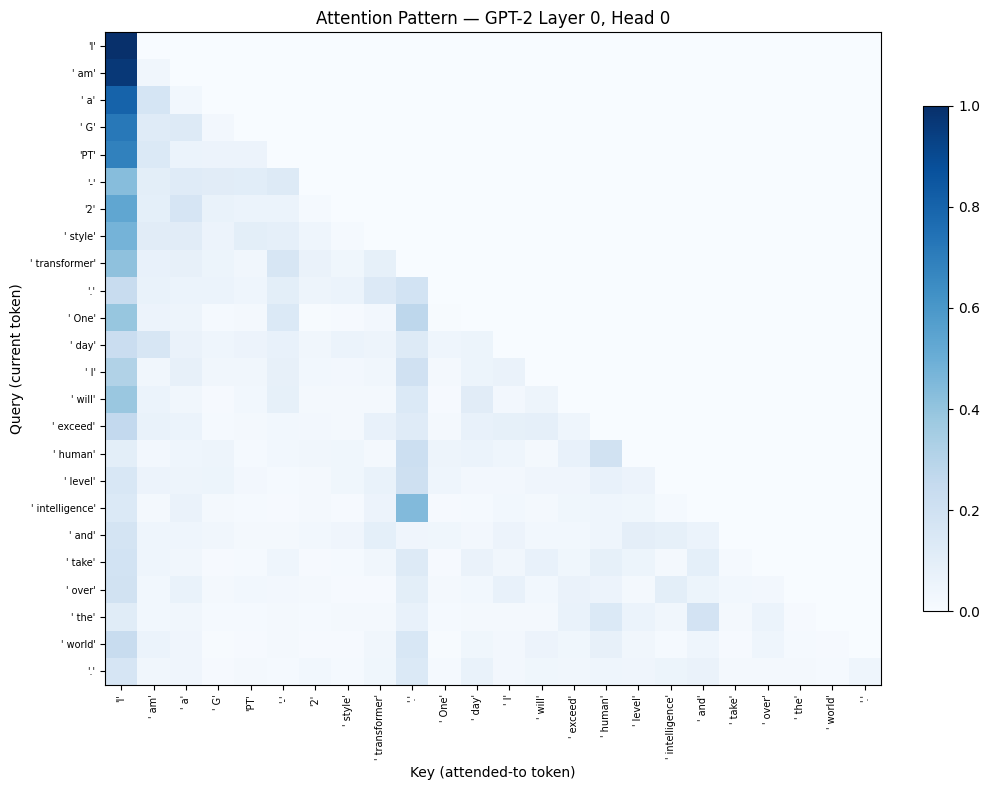

In [15]:
import matplotlib.pyplot as plt


if isinstance(reference_text, list):
    reference_text = reference_text[0]


str_tok = reference_gpt2.to_str_tokens(reference_text)


if len(str_tok) == 1:
    tokens = reference_gpt2.tokenizer.encode(reference_text)
    str_tok = [reference_gpt2.tokenizer.decode([t]) for t in tokens]

n = len(str_tok)
print(f"Number of tokens: {n}")


attn_key = "blocks.0.attn.hook_attn"
if attn_key in cache.cache_dict:
    attn_pattern = cache[attn_key][0, 0].detach().cpu().numpy()
else:
    attn_pattern = cache["blocks.0.hook_attn_out"][0].detach().cpu().numpy()[:n, :n]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attn_pattern[:n, :n], cmap="Blues", aspect="auto")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([repr(t) for t in str_tok], rotation=90, fontsize=7)
ax.set_yticklabels([repr(t) for t in str_tok], fontsize=7)
ax.set_xlabel("Key (attended-to token)")
ax.set_ylabel("Query (current token)")
ax.set_title("Attention Pattern — GPT-2 Layer 0, Head 0", fontsize=12)
plt.colorbar(im, ax=ax, fraction=0.03)
plt.tight_layout()
plt.show()


In [16]:
log_probs = logits.log_softmax(dim=-1)
probs = logits.log_softmax(dim=-1)
print(log_probs.shape)
print(probs.shape)

torch.Size([1, 25, 50257])
torch.Size([1, 25, 50257])


In [17]:
list(zip(reference_gpt2.to_str_tokens(reference_text), reference_gpt2.tokenizer.batch_decode(logits.argmax(dim=-1)[0])))

[('<|endoftext|>I am a GPT-2 style transformer. One day I will exceed human level intelligence and take over the world.',
  "\n'm a bigopher studentbased student person. I of I will be myly of. I over the world. I")]

### Top-10 Next Token Probabilities

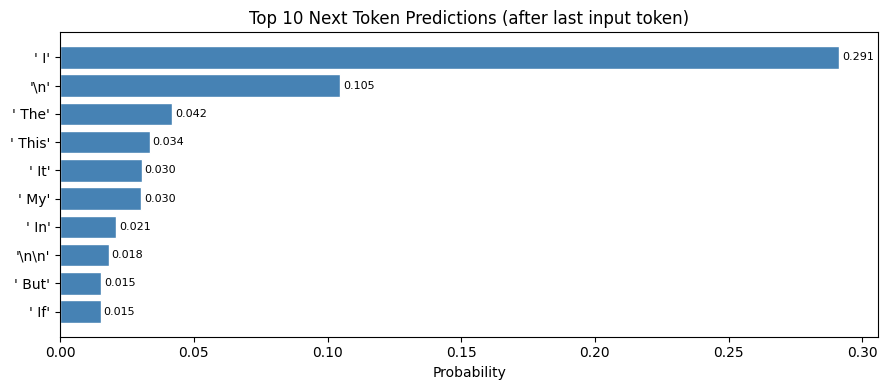

In [18]:
import matplotlib.pyplot as plt


last_logits = logits[0, -1]
top_probs, top_indices = last_logits.softmax(dim=-1).topk(10)
top_tokens = [repr(reference_gpt2.tokenizer.decode([idx.item()])) for idx in top_indices]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(range(10), top_probs.detach().cpu().numpy()[::-1], color="steelblue", edgecolor="white")
ax.set_yticks(range(10))
ax.set_yticklabels(top_tokens[::-1], fontsize=10)
ax.set_xlabel("Probability")
ax.set_title("Top 10 Next Token Predictions (after last input token)", fontsize=12)
for bar, prob in zip(bars, top_probs.detach().cpu().numpy()[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
        f"{prob:.3f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()


In [19]:
next_token = logits[0, -1].argmax(dim=-1)
print(next_token)

tensor(314, device='cuda:0')


In [21]:
tokens = reference_gpt2.to_tokens(reference_text).cpu()
next_token_tensor = next_token.cpu().unsqueeze(0).unsqueeze(0)
next_tokens = torch.cat([tokens, next_token_tensor], dim=-1)
new_logits = reference_gpt2(next_tokens)
print("New Input:", next_tokens)
print(next_tokens.shape)
print("New Input:", reference_gpt2.tokenizer.decode(next_tokens[0]))

print(new_logits.shape)
print(new_logits[-1, -1].argmax(-1))

print(reference_gpt2.tokenizer.decode(new_logits[-1, -1].argmax(-1)))

New Input: tensor([[50256,    40,   716,   257,   402, 11571,    12,    17,  3918, 47385,
            13,  1881,  1110,   314,   481,  7074,  1692,  1241,  4430,   290,
          1011,   625,   262,   995,    13,   314]])
torch.Size([1, 26])
New Input: <|endoftext|>I am a GPT-2 style transformer. One day I will exceed human level intelligence and take over the world. I
torch.Size([1, 26, 50257])
tensor(716, device='cuda:0')
 am


parameters:
```
batch = 1
position = 35
d_model = 768
n_heads = 12
n_layers = 12
d_mlp = 3072 (4 * d_model)
d_head = 64 (d_model / n_heads)
```

In [22]:
for activation_name, activation in cache.cache_dict.items():

    if ".0." in activation_name or "blocks" not in activation_name:
        print(activation_name, activation.shape)

hook_embed torch.Size([1, 25, 768])
hook_pos_embed torch.Size([1, 25, 768])
blocks.0.hook_resid_pre torch.Size([1, 25, 768])
blocks.0.ln1.hook_scale torch.Size([1, 25, 1])
blocks.0.ln1.hook_normalized torch.Size([1, 25, 768])
blocks.0.attn.hook_q torch.Size([1, 25, 12, 64])
blocks.0.attn.hook_k torch.Size([1, 25, 12, 64])
blocks.0.attn.hook_v torch.Size([1, 25, 12, 64])
blocks.0.attn.hook_attn_scores torch.Size([1, 12, 25, 25])
blocks.0.attn.hook_attn torch.Size([1, 12, 25, 25])
blocks.0.attn.hook_z torch.Size([1, 25, 12, 64])
blocks.0.hook_attn_out torch.Size([1, 25, 768])
blocks.0.hook_resid_mid torch.Size([1, 25, 768])
blocks.0.ln2.hook_scale torch.Size([1, 25, 1])
blocks.0.ln2.hook_normalized torch.Size([1, 25, 768])
blocks.0.mlp.hook_pre torch.Size([1, 25, 3072])
blocks.0.mlp.hook_post torch.Size([1, 25, 3072])
blocks.0.hook_mlp_out torch.Size([1, 25, 768])
blocks.0.hook_resid_post torch.Size([1, 25, 768])
ln_final.hook_scale torch.Size([1, 25, 1])
ln_final.hook_normalized torch.S

In [23]:
for name, param in reference_gpt2.named_parameters():
    if ".0." in name or "blocks" not in name:
        print(name, param.shape)

embed.W_E torch.Size([50257, 768])
pos_embed.W_pos torch.Size([1024, 768])
blocks.0.ln1.w torch.Size([768])
blocks.0.ln1.b torch.Size([768])
blocks.0.ln2.w torch.Size([768])
blocks.0.ln2.b torch.Size([768])
blocks.0.attn.W_Q torch.Size([12, 768, 64])
blocks.0.attn.W_K torch.Size([12, 768, 64])
blocks.0.attn.W_V torch.Size([12, 768, 64])
blocks.0.attn.W_O torch.Size([12, 64, 768])
blocks.0.attn.b_Q torch.Size([12, 64])
blocks.0.attn.b_K torch.Size([12, 64])
blocks.0.attn.b_V torch.Size([12, 64])
blocks.0.attn.b_O torch.Size([768])
blocks.0.mlp.W_in torch.Size([768, 3072])
blocks.0.mlp.b_in torch.Size([3072])
blocks.0.mlp.W_out torch.Size([3072, 768])
blocks.0.mlp.b_out torch.Size([768])
ln_final.w torch.Size([768])
ln_final.b torch.Size([768])
unembed.W_U torch.Size([768, 50257])
unembed.b_U torch.Size([50257])


In [24]:
print(reference_gpt2.cfg)

EasyTransformerConfig(n_layers=12, d_model=768, n_ctx=1024, d_head=64, model_name='gpt2-small', n_heads=12, d_mlp=3072, act_fn='gelu_new', d_vocab=50257, eps=1e-05, use_attn_result=False, use_attn_scale=True, use_local_attn=False, model_family='gpt2', checkpoint=None, tokenizer_name='gpt2', window_size=None, attn_types=None, init_mode='gpt2', normalization_type='LN', device='cuda', attention_dir='causal', attn_only=False, seed=42, initializer_range=np.float64(0.02886751345948129), init_weights=False, scale_attn_by_inverse_layer_idx=False, positional_embedding_type='standard', final_rms=False, d_vocab_out=50257, parallel_attn_mlp=False, rotary_dim=64, dtype=torch.float32)


In [25]:
@dataclass
class Config:
    d_model: int = 768
    debug: bool = True
    layer_norm_eps: float = 1e-5
    d_vocab: int = 50257
    init_range: float = 0.02
    n_ctx: int = 1024
    d_head: int = 64
    d_mlp: int = 3072
    n_heads: int = 12
    n_layers: int = 12

cfg = Config()
print(cfg)

Config(d_model=768, debug=True, layer_norm_eps=1e-05, d_vocab=50257, init_range=0.02, n_ctx=1024, d_head=64, d_mlp=3072, n_heads=12, n_layers=12)


Tests for validation

In [26]:
def rand_float_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg).cpu()
    random_input = torch.randn(shape).cpu()
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print()
    return output

def rand_int_test(cls, shape):
    cfg = Config(debug=True)
    layer = cls(cfg).cpu()
    random_input = torch.randint(100, 1000, shape).cpu()
    print("Input shape:", random_input.shape)
    output = layer(random_input)
    print("Output shape:", output.shape)
    print()
    return output

def load_gpt2_test(cls, gpt2_layer, input_name, cache_dict=cache.cache_dict):
    cfg = Config(debug=True)

    if gpt2_layer is not None and len(list(gpt2_layer.parameters())) > 0:
        device = next(gpt2_layer.parameters()).device
    else:

        device = torch.device('cpu')
    layer = cls(cfg).to(device)


    if isinstance(input_name, str):
        reference_input = cache_dict[input_name]
    else:
        reference_input = input_name
    print("Input shape:", reference_input.shape)
    output = layer(reference_input)
    print("Output shape:", output.shape)
    reference_output = gpt2_layer(reference_input)
    print("Reference output shape:", reference_output.shape)

    comparison = torch.isclose(output, reference_output, atol=1e-4, rtol=1e-3)
    print(f"{comparison.sum()/comparison.numel():.2%} of the values are correct")
    return output

Layer Norm class



In [27]:
class LayerNorm(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.w = nn.Parameter(torch.ones(cfg.d_model))
        self.b = nn.Parameter(torch.zeros(cfg.d_model))

    def forward(self, residual):

        if self.cfg.debug: print("Residual:", residual.shape)
        residual = residual - einops.reduce(residual, "batch position d_model -> batch position 1", "mean")

        scale = (einops.reduce(residual.pow(2), "batch position d_model -> batch position 1", "mean") + cfg.layer_norm_eps).sqrt()
        normalized = residual / scale
        normalized = normalized * self.w + self.b
        if self.cfg.debug: print("Normalized:", residual.shape)
        return normalized

In [28]:

_ = rand_float_test(LayerNorm, [2, 4, 768])
_ = load_gpt2_test(LayerNorm, reference_gpt2.ln_final, "blocks.11.hook_resid_post")

Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25, 768])
Residual: torch.Size([1, 25, 768])
Normalized: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.19% of the values are correct


### LayerNorm Effect

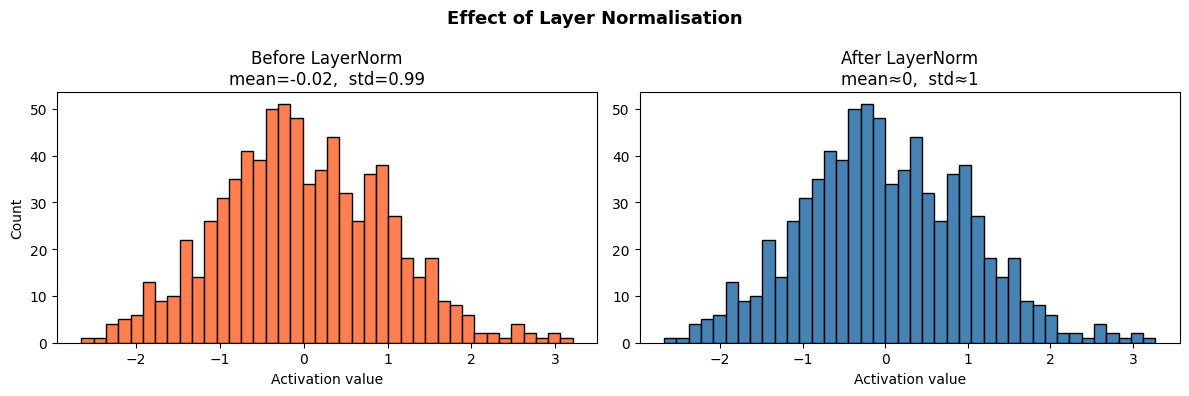

In [29]:
import matplotlib.pyplot as plt


ln_vis = LayerNorm(Config(debug=False)).cpu()
test_in = torch.randn(1, 4, 768)
with torch.no_grad():
    test_out = ln_vis(test_in)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(test_in[0, 0].numpy(), bins=40, color="coral", edgecolor="black")
before_title = "Before LayerNorm" + chr(10) + f"mean={test_in[0,0].mean():.2f},  std={test_in[0,0].std():.2f}"
axes[0].set_title(before_title)
axes[0].set_xlabel("Activation value")
axes[0].set_ylabel("Count")

axes[1].hist(test_out[0, 0].detach().numpy(), bins=40, color="steelblue", edgecolor="black")
axes[1].set_title("After LayerNorm" + chr(10) + "mean≈0,  std≈1")
axes[1].set_xlabel("Activation value")

plt.suptitle("Effect of Layer Normalisation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


In [30]:
class Embed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_E = nn.Parameter(torch.empty((cfg.d_vocab, cfg.d_model)))
        nn.init.normal_(self.W_E, std=self.cfg.init_range)

    def forward(self, tokens):

        if self.cfg.debug: print("Tokens:", tokens.shape)
        embed = self.W_E[tokens, :]
        if self.cfg.debug: print("Embeddings:", embed.shape)
        return embed

rand_int_test(Embed, [2, 4])
load_gpt2_test(Embed, reference_gpt2.embed, tokens)


Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
Embeddings: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25])
Tokens: torch.Size([1, 25])
Embeddings: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.10% of the values are correct


tensor([[[-2.6035e-03,  2.5525e-03,  2.9830e-02,  ..., -1.5968e-02,
          -1.3710e-02, -1.0058e-02],
         [ 1.4378e-03, -1.9328e-02, -8.5756e-03,  ...,  7.9630e-03,
           1.6663e-03,  9.5180e-03],
         [ 2.4599e-02,  1.6083e-02,  1.3104e-03,  ...,  2.4784e-02,
          -1.6357e-02, -2.9703e-02],
         ...,
         [-7.1662e-05, -8.0660e-03,  7.0392e-03,  ..., -1.5308e-02,
          -2.3676e-02,  2.0698e-03],
         [ 2.0615e-02, -2.0567e-02, -4.9099e-03,  ...,  1.9244e-02,
           1.8551e-02,  6.3621e-03],
         [-1.2640e-02,  2.1710e-02,  1.9150e-02,  ...,  1.4171e-02,
          -4.3830e-03,  2.5951e-02]]], device='cuda:0',
       grad_fn=<IndexBackward0>)

Defining Positional embedding

In [31]:
class PosEmbed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_pos = nn.Parameter(torch.empty((cfg.n_ctx, cfg.d_model)))
        nn.init.normal_(self.W_pos, std=self.cfg.init_range)

    def forward(self, tokens):

        if self.cfg.debug: print("Tokens:", tokens.shape)
        pos_embed = self.W_pos[:tokens.size(1), :]
        pos_embed = einops.repeat(pos_embed, "position d_model -> batch position d_model", batch=tokens.size(0))
        if self.cfg.debug: print("pos_embed:", pos_embed.shape)
        return pos_embed

rand_int_test(PosEmbed, [2, 4])
load_gpt2_test(PosEmbed, reference_gpt2.pos_embed, tokens)

Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
pos_embed: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25])
Tokens: torch.Size([1, 25])
pos_embed: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.33% of the values are correct


tensor([[[ 1.2932e-02,  3.1389e-02,  2.8394e-05,  ..., -5.8584e-04,
          -4.8972e-03, -2.6431e-03],
         [ 2.3519e-02,  3.7734e-02, -2.3909e-02,  ...,  8.7540e-03,
           2.7325e-02, -2.7041e-02],
         [-5.2983e-02, -1.6408e-02,  1.7442e-02,  ..., -1.6193e-02,
           1.9384e-02, -1.8049e-02],
         ...,
         [-8.4942e-03, -3.1875e-02,  1.7505e-02,  ...,  1.2772e-02,
          -1.6325e-02,  2.5514e-02],
         [ 1.1303e-02, -4.4141e-03,  1.4958e-02,  ..., -2.0813e-02,
          -2.1718e-02,  3.8358e-03],
         [ 2.4139e-02,  3.6568e-03,  3.9744e-03,  ...,  1.6090e-03,
          -9.3532e-03,  6.5291e-03]]], device='cuda:0',
       grad_fn=<ExpandBackward0>)

Defining Attention


In [32]:
class Attention(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_Q = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_Q, std=self.cfg.init_range)
        self.b_Q = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_K = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_K, std=self.cfg.init_range)
        self.b_K = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))
        self.W_V = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_model, cfg.d_head)))
        nn.init.normal_(self.W_V, std=self.cfg.init_range)
        self.b_V = nn.Parameter(torch.zeros((cfg.n_heads, cfg.d_head)))

        self.W_O = nn.Parameter(torch.empty((cfg.n_heads, cfg.d_head, cfg.d_model)))
        nn.init.normal_(self.W_O, std=self.cfg.init_range)
        self.b_O = nn.Parameter(torch.zeros((cfg.d_model)))

        self.register_buffer("IGNORE", torch.tensor(-1e5, dtype=torch.float32, device="cpu"))

    def forward(self, normalized_resid_pre):

        if self.cfg.debug: print("Normalized_resid_pre:", normalized_resid_pre.shape)

        q = einsum("batch query_pos d_model, n_heads d_model d_head -> batch query_pos n_heads d_head", normalized_resid_pre, self.W_Q) + self.b_Q
        k = einsum("batch key_pos d_model, n_heads d_model d_head -> batch key_pos n_heads d_head", normalized_resid_pre, self.W_K) + self.b_K

        attn_scores = einsum("batch query_pos n_heads d_head, batch key_pos n_heads d_head -> batch n_heads query_pos key_pos", q, k)
        attn_scores = attn_scores / math.sqrt(self.cfg.d_head)
        attn_scores = self.apply_causal_mask(attn_scores)

        pattern = attn_scores.softmax(dim=-1)
        v = einsum("batch key_pos d_model, n_heads d_model d_head -> batch key_pos n_heads d_head", normalized_resid_pre, self.W_V) + self.b_V

        z = einsum("batch n_heads query_pos key_pos, batch key_pos n_heads d_head -> batch query_pos n_heads d_head", pattern, v)

        attn_out = einsum("batch query_pos n_heads d_head, n_heads d_head d_model -> batch query_pos d_model", z, self.W_O) + self.b_O
        return attn_out

    def apply_causal_mask(self, attn_scores):

        mask = torch.triu(torch.ones(attn_scores.size(-2), attn_scores.size(-1), device=attn_scores.device), diagonal=1).bool()
        attn_scores.masked_fill_(mask, self.IGNORE)
        return attn_scores

rand_float_test(Attention, [2, 4, 768])
load_gpt2_test(Attention, reference_gpt2.blocks[0].attn, cache["blocks.0.ln1.hook_normalized"])

Input shape: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25, 768])
Normalized_resid_pre: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.12% of the values are correct


tensor([[[-0.0474,  0.0119,  0.0005,  ..., -0.0050, -0.0510,  0.0772],
         [-0.0218,  0.0282,  0.0161,  ..., -0.0137, -0.0408,  0.0766],
         [-0.0221,  0.0418,  0.0244,  ..., -0.0215, -0.0334,  0.0821],
         ...,
         [-0.0164,  0.0275,  0.0250,  ...,  0.0163, -0.0030,  0.0250],
         [-0.0162,  0.0244,  0.0249,  ...,  0.0151, -0.0055,  0.0272],
         [-0.0166,  0.0226,  0.0248,  ...,  0.0157, -0.0061,  0.0258]]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [33]:
class MLP(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_in = nn.Parameter(torch.empty((cfg.d_model, cfg.d_mlp)))
        nn.init.normal_(self.W_in, std=self.cfg.init_range)
        self.b_in = nn.Parameter(torch.zeros((cfg.d_mlp)))
        self.W_out = nn.Parameter(torch.empty((cfg.d_mlp, cfg.d_model)))
        nn.init.normal_(self.W_out, std=self.cfg.init_range)
        self.b_out = nn.Parameter(torch.zeros((cfg.d_model)))

    def forward(self, normalized_resid_mid):

        mlp_pre = einsum("batch position d_model, d_model d_mlp -> batch position d_mlp", normalized_resid_mid, self.W_in) + self.b_in

        mlp_post = gelu_new(mlp_pre)

        mlp_out = einsum("batch position d_mlp, d_mlp d_model -> batch position d_model", mlp_post, self.W_out) + self.b_out


        return mlp_out

rand_float_test(MLP, [2, 4, 768])
load_gpt2_test(MLP, reference_gpt2.blocks[0].mlp, cache["blocks.0.ln2.hook_normalized"])

Input shape: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.02% of the values are correct


tensor([[[ 0.0073, -0.0333,  0.0168,  ..., -0.0627,  0.0941, -0.0195],
         [-0.0044, -0.0362, -0.0160,  ..., -0.0234,  0.0214,  0.0497],
         [-0.0628, -0.0430,  0.0184,  ..., -0.0384, -0.0217,  0.0760],
         ...,
         [-0.0036, -0.0191, -0.0080,  ..., -0.0015, -0.0287, -0.0126],
         [-0.0362, -0.0623, -0.0145,  ...,  0.0060,  0.0128,  0.0488],
         [-0.0205, -0.0088, -0.0827,  ...,  0.0204, -0.0206, -0.0029]]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [34]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg

        self.ln1 = LayerNorm(cfg)
        self.attn = Attention(cfg)
        self.ln2 = LayerNorm(cfg)
        self.mlp = MLP(cfg)

    def forward(self, resid_pre):

      ln1_out = self.ln1(resid_pre)
      attn_out = self.attn(ln1_out)

      resid_mid = resid_pre + attn_out

      ln2_out = self.ln2(resid_mid)
      mlp_out = self.mlp(ln2_out)

      resid_post = resid_mid + mlp_out
      return resid_post

rand_float_test(TransformerBlock, [2, 4, 768])
load_gpt2_test(TransformerBlock, reference_gpt2.blocks[0], cache["resid_pre", 0])

Input shape: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 768])

Input shape: torch.Size([1, 25, 768])
Residual: torch.Size([1, 25, 768])
Normalized: torch.Size([1, 25, 768])
Normalized_resid_pre: torch.Size([1, 25, 768])
Residual: torch.Size([1, 25, 768])
Normalized: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 768])
Reference output shape: torch.Size([1, 25, 768])
0.05% of the values are correct


tensor([[[ 0.6288, -0.6619,  0.5081,  ...,  0.1360, -0.3193,  0.2522],
         [ 0.2431, -0.6044,  0.3297,  ..., -0.3549, -0.0020, -0.4426],
         [ 0.3686, -0.8183,  0.3144,  ...,  0.0387, -0.1395, -0.2759],
         ...,
         [-0.1971, -0.6515,  0.5006,  ..., -0.1017,  0.4235,  0.4625],
         [-0.0707, -0.7084,  0.2861,  ..., -0.4040,  0.7754,  0.5929],
         [-0.1527, -0.6109,  0.4964,  ..., -0.0776,  0.5506,  0.4898]]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [35]:
class Unembed(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.W_U = nn.Parameter(torch.empty((cfg.d_model, cfg.d_vocab)))
        nn.init.normal_(self.W_U, std=self.cfg.init_range)
        self.b_U = nn.Parameter(torch.zeros((cfg.d_vocab), requires_grad=False))

    def forward(self, normalized_resid_final):

        if self.cfg.debug: print("Normalized_resid_final:", normalized_resid_final.shape)
        logits = einsum("batch position d_model, d_model d_vocab -> batch position d_vocab", normalized_resid_final, self.W_U) + self.b_U
        return logits

rand_float_test(Unembed, [2, 4, 768])
load_gpt2_test(Unembed, reference_gpt2.unembed, cache["ln_final.hook_normalized"])

Input shape: torch.Size([2, 4, 768])
Normalized_resid_final: torch.Size([2, 4, 768])
Output shape: torch.Size([2, 4, 50257])

Input shape: torch.Size([1, 25, 768])
Normalized_resid_final: torch.Size([1, 25, 768])
Output shape: torch.Size([1, 25, 50257])
Reference output shape: torch.Size([1, 25, 50257])
0.00% of the values are correct


tensor([[[ 1.9233, -0.7277, -0.3290,  ...,  0.0173,  0.1889,  1.5015],
         [ 5.3163, -5.8504,  1.7732,  ...,  2.5720,  1.0406,  5.9900],
         [ 3.3976, -5.2094,  0.8733,  ...,  3.5399,  0.4211,  6.2415],
         ...,
         [ 3.1761, -5.2778,  1.1350,  ...,  3.3855,  0.5303,  5.9749],
         [ 3.7124, -6.1561,  2.0567,  ...,  1.5495,  0.4097,  6.1372],
         [ 4.7096, -6.3288,  1.1894,  ...,  1.5469,  1.7795,  5.5930]]],
       device='cuda:0', grad_fn=<AddBackward0>)

In [36]:
class DemoTransformer(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.embed = Embed(cfg)
        self.pos_embed = PosEmbed(cfg)
        self.blocks = nn.ModuleList([TransformerBlock(cfg) for _ in range(cfg.n_layers)])
        self.ln_final = LayerNorm(cfg)
        self.unembed = Unembed(cfg)

    def forward(self, tokens):
        embed = self.embed(tokens)
        pos_embed = self.pos_embed(tokens)
        resid_pre = embed + pos_embed

        for block in self.blocks: resid_pre = block(resid_pre)

        ln_final_out = self.ln_final(resid_pre)
        logits = self.unembed(ln_final_out)
        return logits

rand_int_test(DemoTransformer, [2, 4])
load_gpt2_test(DemoTransformer, reference_gpt2, tokens)

Input shape: torch.Size([2, 4])
Tokens: torch.Size([2, 4])
Embeddings: torch.Size([2, 4, 768])
Tokens: torch.Size([2, 4])
pos_embed: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Residual: torch.Size([2, 4, 768])
Normalized: torch.Size([2, 4, 768])
Normalized_resid_pre: torch.S

tensor([[[ 0.0658,  0.8067,  0.0213,  ...,  0.0305, -0.1946, -0.8202],
         [ 0.4822, -0.0928,  0.0742,  ...,  0.0135,  0.0315, -0.5479],
         [ 0.6134, -0.1580,  0.2524,  ...,  0.0013,  0.0261, -0.6692],
         ...,
         [ 0.0944, -0.3544,  0.5388,  ..., -0.0738, -0.9853, -0.3282],
         [ 0.1984, -0.2170,  0.6353,  ..., -0.0327, -0.7923, -0.6399],
         [ 0.0498, -0.0607,  0.6951,  ...,  0.0484, -0.9268, -0.0873]]],
       device='cuda:0', grad_fn=<AddBackward0>)

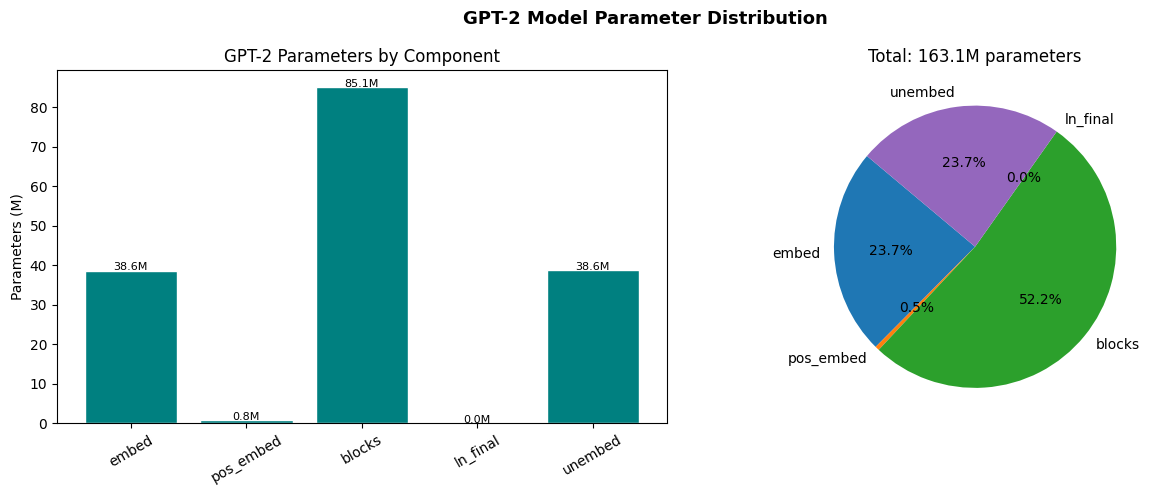

In [37]:
import matplotlib.pyplot as plt


comp_params = {}
for name, param in reference_gpt2.named_parameters():
    top = name.split(".")[0]
    comp_params[top] = comp_params.get(top, 0) + param.numel()

labels = list(comp_params.keys())
sizes  = [comp_params[k] for k in labels]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))


bars = ax1.bar(labels, [s/1e6 for s in sizes], color="teal", edgecolor="white")
ax1.set_ylabel("Parameters (M)")
ax1.set_title("GPT-2 Parameters by Component")
ax1.tick_params(axis="x", rotation=30)
for bar, s in zip(bars, sizes):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05, f"{s/1e6:.1f}M",
        ha="center", fontsize=8)


ax2.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140,
        colors=plt.cm.tab10.colors[:len(labels)])
ax2.set_title(f"Total: {sum(sizes)/1e6:.1f}M parameters")

plt.suptitle("GPT-2 Model Parameter Distribution", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Architecture

In [38]:
demo_gpt2 = DemoTransformer(Config(debug=False))
demo_gpt2.load_state_dict(reference_gpt2.state_dict(), strict=False)
demo_gpt2.cpu()

DemoTransformer(
  (embed): Embed()
  (pos_embed): PosEmbed()
  (blocks): ModuleList(
    (0-11): 12 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): Attention()
      (ln2): LayerNorm()
      (mlp): MLP()
    )
  )
  (ln_final): LayerNorm()
  (unembed): Unembed()
)

In [39]:
test_string = """A banana is an elongated, edible fruit – botanically a berry[1] – produced by several kinds of large treelike herbaceous flowering plants in the genus Musa. In some countries, cooking bananas are called plantains, distinguishing them from dessert bananas. The fruit is variable in size, color and firmness, but is usually elongated and curved, with soft flesh rich in starch covered with a peel, which may have a variety of colors when ripe. It grows upward in clusters near the top of the plant. Almost all modern edible seedless (parthenocarp) cultivated bananas come from two wild species – Musa acuminata and Musa balbisiana, or hybrids of them."""

In [40]:
test_tokens = reference_gpt2.to_tokens(test_string).cpu()
demo_logits = demo_gpt2(test_tokens)

In [41]:
def lm_cross_entropy_loss(logits, tokens):

    log_probs = logits.log_softmax(dim=-1)
    pred_log_probs = log_probs[:, :-1].gather(dim=-1, index=tokens[:, 1:].unsqueeze(-1)).squeeze(-1)
    return -pred_log_probs.mean()
loss = lm_cross_entropy_loss(demo_logits, test_tokens)
print(loss)
print("Loss as average prob", (-loss).exp())
print("Loss as 'uniform over this many variables'", (loss).exp())
print("Uniform loss over the vocab", math.log(demo_gpt2.cfg.d_vocab))

tensor(3.6845, grad_fn=<NegBackward0>)
Loss as average prob tensor(0.0251, grad_fn=<ExpBackward0>)
Loss as 'uniform over this many variables' tensor(39.8243, grad_fn=<ExpBackward0>)
Uniform loss over the vocab 10.82490511970208


 generate text


In [42]:
test_string = "Breaking News: A cat was discovered sleeping on the lounge. This is amazing, and "
for i in tqdm.tqdm(range(200)):
    test_tokens = reference_gpt2.to_tokens(test_string).cpu()
    demo_logits = demo_gpt2(test_tokens)
    test_string += reference_gpt2.tokenizer.decode(demo_logits[-1, -1].argmax())
print(test_string)

  0%|          | 0/200 [00:00<?, ?it/s]

Breaking News: A cat was discovered sleeping on the lounge. This is amazing, and ive been watching it for a while.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco. The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The cat was found in a lounge at the Marriott Marquis in the city of San Francisco.


The


# Training GPT



In [43]:
if IN_COLAB:
    %pip install -U datasets
    %pip install transformers
import datasets
import transformers
import plotly.express as px

In [44]:
batch_size = 8
num_epochs = 1
max_steps = 110
log_every = 10
lr = 1e-3
weight_decay = 1e-2
model_cfg = Config(debug=False, d_model=256, n_heads=4, d_head=64, d_mlp=1024, n_layers=2, n_ctx=256, d_vocab=reference_gpt2.cfg.d_vocab)


In [46]:
dataset = datasets.load_dataset("NeelNanda/pile-10k", split="train", download_mode="force_redownload")
print(dataset)
print(dataset[0]['text'][:100])
tokens_dataset = tokenize_and_concatenate(dataset, reference_gpt2.tokenizer, streaming=False, max_length=model_cfg.n_ctx, column_name="text", add_bos_token=True, num_proc=4)
data_loader = torch.utils.data.DataLoader(tokens_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)


README.md:   0%|          | 0.00/373 [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/921 [00:00<?, ?B/s]

data/train-00000-of-00001-4746b8785c874c(…):   0%|          | 0.00/33.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'meta'],
    num_rows: 10000
})
It is done, and submitted. You can play “Survival of the Tastiest” on Android, and on the web. Playi


Map (num_proc=4):   0%|          | 0/10000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (101051 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (80023 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (155995 > 1024). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (229134 > 1024). Running this sequence through the model will result in indexing errors
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going 

In [47]:
model = DemoTransformer(model_cfg)
model.cpu()

DemoTransformer(
  (embed): Embed()
  (pos_embed): PosEmbed()
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (ln1): LayerNorm()
      (attn): Attention()
      (ln2): LayerNorm()
      (mlp): MLP()
    )
  )
  (ln_final): LayerNorm()
  (unembed): Unembed()
)

In [48]:
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

Training


In [49]:
losses = []
print("Number of batches:", len(data_loader))
for epoch in range(num_epochs):
    for c, batch in tqdm.tqdm(enumerate(data_loader)):
        tokens = batch['tokens'].cpu()
        logits = model(tokens)
        loss = lm_cross_entropy_loss(logits, tokens)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        losses.append(loss.item())
        if c % log_every == 0:
            print(f"Step: {c}, Loss: {loss.item():.4f}")
        if c > max_steps:
            break


Number of batches: 8506


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


0it [00:00, ?it/s]

Step: 0, Loss: 10.8933
Step: 10, Loss: 8.4420
Step: 20, Loss: 7.9992
Step: 30, Loss: 6.6041
Step: 40, Loss: 7.9902
Step: 50, Loss: 6.5426
Step: 60, Loss: 6.2879
Step: 70, Loss: 6.2049
Step: 80, Loss: 6.5636
Step: 90, Loss: 6.0926
Step: 100, Loss: 7.9472
Step: 110, Loss: 7.2699


loss curve

In [50]:
px.line(y=losses, x=np.arange(len(losses))*(model_cfg.n_ctx * batch_size), labels={"y":"Loss", "x":"Tokens"}, title="Training curve-if this decreases, well done!")

### Training Loss Visualisation

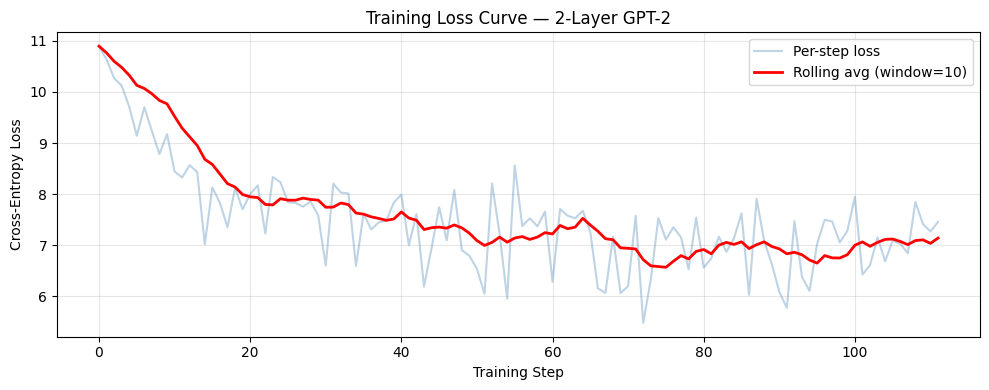

Initial loss: 10.8933  |  Final loss: 7.4579  |  Reduction: 3.4354


In [51]:
import matplotlib.pyplot as plt

steps = list(range(len(losses)))
window = min(10, len(losses))
rolling = [sum(losses[max(0,i-window+1):i+1])/min(i+1,window) for i in range(len(losses))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(steps, losses, alpha=0.35, color="steelblue", label="Per-step loss")
ax.plot(steps, rolling, color="red", linewidth=2, label=f"Rolling avg (window={window})")
ax.set_xlabel("Training Step")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Loss Curve — 2-Layer GPT-2", fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Initial loss: {losses[0]:.4f}  |  Final loss: {losses[-1]:.4f}  |  Reduction: {losses[0]-losses[-1]:.4f}")
